# 2026 SSN Player Glicko-2 Ratings & Matchup Analysis

Player Glicko-2 ratings for the 2026 Super Netball season. Ratings are built by
replaying all historical matches, then filtered to show only active 2026 squad players.

In [6]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)

from netball_model.data.database import Database
from netball_model.features.builder import FeatureBuilder
from netball_model.features.player_rankings import (
    get_position_rankings,
    get_team_matchup_report,
)
from netball_model.data.squads import get_all_squads
from netball_model.data.player_movements import _find_player_id_by_name

# --- Bootstrap: load data ---
db = Database('../data/netball.db')
matches = db.get_matches()

player_stats = {}
for m in matches:
    starters = db.get_starters_for_match(m['match_id'])
    if starters:
        player_stats[m['match_id']] = starters

builder = FeatureBuilder(matches, player_stats=player_stats)

# --- Replay with rating snapshots ---
# Instead of build_matrix(), manually advance _ensure_elo_up_to one match at a
# time so we can capture the full rating state after each update.
history_rows = []
for i in range(1, len(matches) + 1):
    builder._ensure_elo_up_to(i)          # processes match at index i-1
    m = matches[i - 1]
    for (pid, pos), pr in builder._player_glicko._ratings.items():
        history_rows.append({
            'match_index': i - 1,
            'season': m.get('season'),
            'player_id': pid,
            'position': pos,
            'rating': pr.rating,
            'rd': pr.rd,
        })

history_df = pd.DataFrame(history_rows)
glicko = builder._player_glicko

# Season boundaries for trajectory plots
season_boundaries = []
for i in range(1, len(matches)):
    if matches[i].get('season') != matches[i - 1].get('season'):
        season_boundaries.append(i)

# Build player_map from latest appearances
player_map = {}
for starters_list in player_stats.values():
    for s in starters_list:
        player_map[s['player_id']] = {
            'player_name': s['player_name'],
            'team': s['team'],
        }

# Resolve 2026 squad names to player_ids
squads_2026 = get_all_squads(2026)
squad_ids = {}  # {team: {position: player_id}}
for team, positions in squads_2026.items():
    squad_ids[team] = {}
    for pos, name in positions.items():
        pid = _find_player_id_by_name(name, matches, db)
        if pid:
            squad_ids[team][pos] = pid

squad_2026_pids = set()
for team_squads in squad_ids.values():
    squad_2026_pids.update(team_squads.values())

# Summary
n_rated = len(glicko._ratings)
unique_players = len(set(pid for pid, _ in glicko._ratings.keys()))
teams_2026 = list(squads_2026.keys())

print(f'Matches replayed: {len(matches)}')
print(f'Player-position ratings: {n_rated}')
print(f'Unique players rated: {unique_players}')
print(f'Rating snapshots: {len(history_df):,}')
print(f'Season boundaries: {season_boundaries}')
print(f'2026 teams: {len(teams_2026)}')
print()
for team in sorted(teams_2026):
    resolved = len(squad_ids.get(team, {}))
    total = len(squads_2026[team])
    print(f'  {team}: {resolved}/{total} players resolved')

Matches replayed: 595
Player-position ratings: 323
Unique players rated: 194
Rating snapshots: 133,771
Season boundaries: [60, 120, 180, 240, 299, 359, 419, 479, 539]
2026 teams: 8

  Adelaide Thunderbirds: 3/7 players resolved
  GIANTS Netball: 5/7 players resolved
  Melbourne Mavericks: 5/7 players resolved
  Melbourne Vixens: 7/7 players resolved
  NSW Swifts: 6/7 players resolved
  Queensland Firebirds: 4/7 players resolved
  Sunshine Coast Lightning: 5/7 players resolved
  West Coast Fever: 7/7 players resolved


## Position Power Rankings — 2026 Squads

2026 squad players at each position, ranked by Glicko-2 rating.
Lower RD (rating deviation) indicates more certainty in the rating.
Players new to the league won't appear (unresolved from historical data).

In [7]:
positions = ['GS', 'GA', 'WA', 'C', 'WD', 'GD', 'GK']

for pos in positions:
    rankings = get_position_rankings(glicko, player_map, pos)
    active = [r for r in rankings if r['player_id'] in squad_2026_pids]
    if not active:
        print(f'\n=== {pos} === (no resolved players)')
        continue

    df = pd.DataFrame(active)
    df = df[['rank', 'player_name', 'team', 'rating', 'rd']]
    df['rating'] = df['rating'].round(0).astype(int)
    df['rd'] = df['rd'].round(0).astype(int)
    df['rank'] = range(1, len(df) + 1)

    print(f'\n=== {pos} ===')
    display(
        df.style
        .set_properties(**{'color': '#1a1a1a', 'background-color': '#F5F5F5'})
        .hide(axis='index')
        .set_caption(f'{pos} — 2026 Squad Players')
    )


=== GS ===


rank,player_name,team,rating,rd
1,Shimona Nelson,Melbourne Mavericks,1754,155
2,Romelda Aiken-George,Adelaide Thunderbirds,1746,155
3,Sophie Garbin,Melbourne Vixens,1745,156
4,Mary Cholhok,Queensland Firebirds,1714,179
5,Grace Nweke,NSW Swifts,1709,170
6,Donnell Wallam,Queensland Firebirds,1681,185
7,Reilley Batcheldor,Sunshine Coast Lightning,1622,246
8,Helen Housby,NSW Swifts,1609,241
9,Lucy Austin,Adelaide Thunderbirds,1575,301
10,Sasha Glasgow,Melbourne Mavericks,1530,350



=== GA ===


rank,player_name,team,rating,rd
1,Kiera Austin,Melbourne Vixens,1986,247
2,Helen Housby,NSW Swifts,1966,280
3,Sasha Glasgow,Melbourne Mavericks,1936,255
4,Sophie Dwyer,GIANTS Netball,1933,244
5,Sophie Garbin,Melbourne Vixens,1773,317
6,Alice Teague-Neeld,West Coast Fever,1708,350
7,Georgie Horjus,Adelaide Thunderbirds,1684,350
8,Reilley Batcheldor,Sunshine Coast Lightning,1605,350



=== WA ===


...

rank,player_name,team,rating,rd
1,Maddy Proud,NSW Swifts,1488,350
2,Tara Hinchliffe,Sunshine Coast Lightning,1452,350
3,Rudi Ellis,Melbourne Vixens,1431,350
4,Jamie-Lee Price,GIANTS Netball,1391,350
5,Fran Williams,West Coast Fever,1250,281
6,Jo Weston,Melbourne Vixens,1209,327
7,Kate Eddy,Melbourne Vixens,1193,287
8,Maddy Turner,NSW Swifts,1182,337
9,Latanya Wilson,Adelaide Thunderbirds,1160,245
10,Amy Sligar,GIANTS Netball,1140,254



=== GD ===


rank,player_name,team,rating,rd
1,Teigan O'Shannassy,NSW Swifts,1374,337
2,Sarah Klau,NSW Swifts,1362,289
3,Kate Eddy,Melbourne Vixens,1361,349
4,Latanya Wilson,Adelaide Thunderbirds,1284,270
5,Fran Williams,West Coast Fever,1243,282
6,Erin O'Brien,GIANTS Netball,1183,283
7,Maddy Turner,NSW Swifts,1092,262
8,Matilda Garrett,Adelaide Thunderbirds,1088,241
9,Jo Weston,Melbourne Vixens,1063,265
10,Ruby Bakewell-Doran,Queensland Firebirds,1060,261



=== GK ===


rank,player_name,team,rating,rd
1,Fran Williams,West Coast Fever,1479,223
2,Ruby Bakewell-Doran,Queensland Firebirds,1461,311
3,Jo Weston,Melbourne Vixens,1458,303
4,Maddy Turner,NSW Swifts,1454,350
5,Tara Hinchliffe,Sunshine Coast Lightning,1407,258
6,Latanya Wilson,Adelaide Thunderbirds,1394,226
7,Teigan O'Shannassy,NSW Swifts,1385,260
8,Matilda Garrett,Adelaide Thunderbirds,1371,228
9,Erin O'Brien,GIANTS Netball,1335,214
10,Rudi Ellis,Melbourne Vixens,1276,169


## 2026 Team Strength

Average player Glicko-2 rating across each team's announced 2026 squad,
broken down into attack (GS + GA), midcourt (WA + C + WD), and defence (GD + GK).
Teams with unresolved players show ratings for resolved positions only.

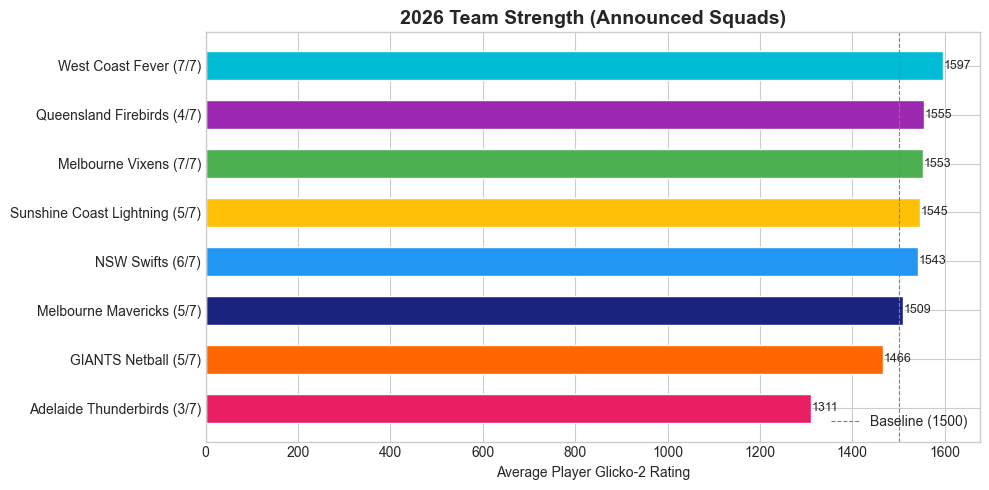

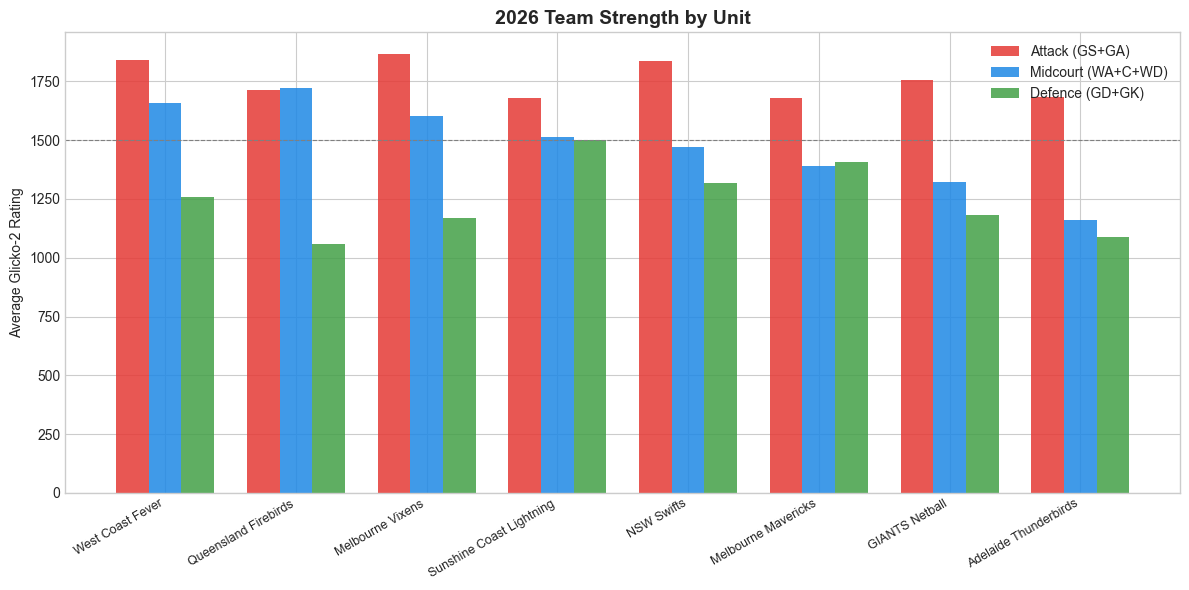

In [8]:
# Build team strength from 2026 squad assignments
attack_pos = ['GS', 'GA']
mid_pos = ['WA', 'C', 'WD']
def_pos = ['GD', 'GK']

team_data = []
for team in sorted(squad_ids.keys()):
    team_sq = squad_ids[team]
    pos_ratings = {}
    for pos, pid in team_sq.items():
        pos_ratings[pos] = glicko.get_rating(pid, pos).rating

    all_vals = list(pos_ratings.values())
    att_vals = [pos_ratings[p] for p in attack_pos if p in pos_ratings]
    mid_vals = [pos_ratings[p] for p in mid_pos if p in pos_ratings]
    def_vals = [pos_ratings[p] for p in def_pos if p in pos_ratings]

    team_data.append({
        'team': team,
        'overall': np.mean(all_vals) if all_vals else 1500,
        'attack': np.mean(att_vals) if att_vals else 1500,
        'midcourt': np.mean(mid_vals) if mid_vals else 1500,
        'defence': np.mean(def_vals) if def_vals else 1500,
        'resolved': f'{len(team_sq)}/7',
    })

team_df = pd.DataFrame(team_data).sort_values('overall', ascending=True)

TEAM_COLORS = {
    'Adelaide Thunderbirds': '#E91E63',
    'GIANTS Netball': '#FF6600',
    'Melbourne Mavericks': '#1A237E',
    'Melbourne Vixens': '#4CAF50',
    'NSW Swifts': '#2196F3',
    'Queensland Firebirds': '#9C27B0',
    'Sunshine Coast Lightning': '#FFC107',
    'West Coast Fever': '#00BCD4',
}

# --- Chart 1: Overall strength horizontal bar ---
fig, ax = plt.subplots(figsize=(10, 5))
colors = [TEAM_COLORS.get(t, '#666') for t in team_df['team']]
labels = [f"{t} ({r})" for t, r in zip(team_df['team'], team_df['resolved'])]
bars = ax.barh(labels, team_df['overall'], color=colors, edgecolor='white', height=0.6)
ax.set_xlabel('Average Player Glicko-2 Rating')
ax.set_title('2026 Team Strength (Announced Squads)', fontsize=14, fontweight='bold')
ax.axvline(1500, color='grey', ls='--', lw=0.8, label='Baseline (1500)')

for bar, val in zip(bars, team_df['overall']):
    ax.text(val + 2, bar.get_y() + bar.get_height() / 2, f'{val:.0f}',
            va='center', fontsize=9)

ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# --- Chart 2: Attack / Midcourt / Defence grouped bars ---
team_df_sorted = team_df.sort_values('overall', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(team_df_sorted))
width = 0.25

ax.bar(x - width, team_df_sorted['attack'], width, label='Attack (GS+GA)',
       color='#E53935', alpha=0.85)
ax.bar(x, team_df_sorted['midcourt'], width, label='Midcourt (WA+C+WD)',
       color='#1E88E5', alpha=0.85)
ax.bar(x + width, team_df_sorted['defence'], width, label='Defence (GD+GK)',
       color='#43A047', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(team_df_sorted['team'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Average Glicko-2 Rating')
ax.set_title('2026 Team Strength by Unit', fontsize=14, fontweight='bold')
ax.axhline(1500, color='grey', ls='--', lw=0.8)
ax.legend()
plt.tight_layout()
plt.show()

## Rating Trajectories — 2026 Stars

Rating evolution for the top 5 rated 2026 squad players across all positions.
Vertical dashed lines mark season boundaries where the 20% regression toward
1500 and +30 RD increase take effect — visible as sharp downward pulls.

Top 5 rated 2026 squad players:


player_name,position,team,rating
Liz Watson,WA,Sunshine Coast Lightning,2199
Alice Teague-Neeld,WA,West Coast Fever,2191
Georgie Horjus,WA,Adelaide Thunderbirds,2124
Lara Dunkley,WA,Queensland Firebirds,2063
Hannah Mundy,WA,Melbourne Vixens,1990


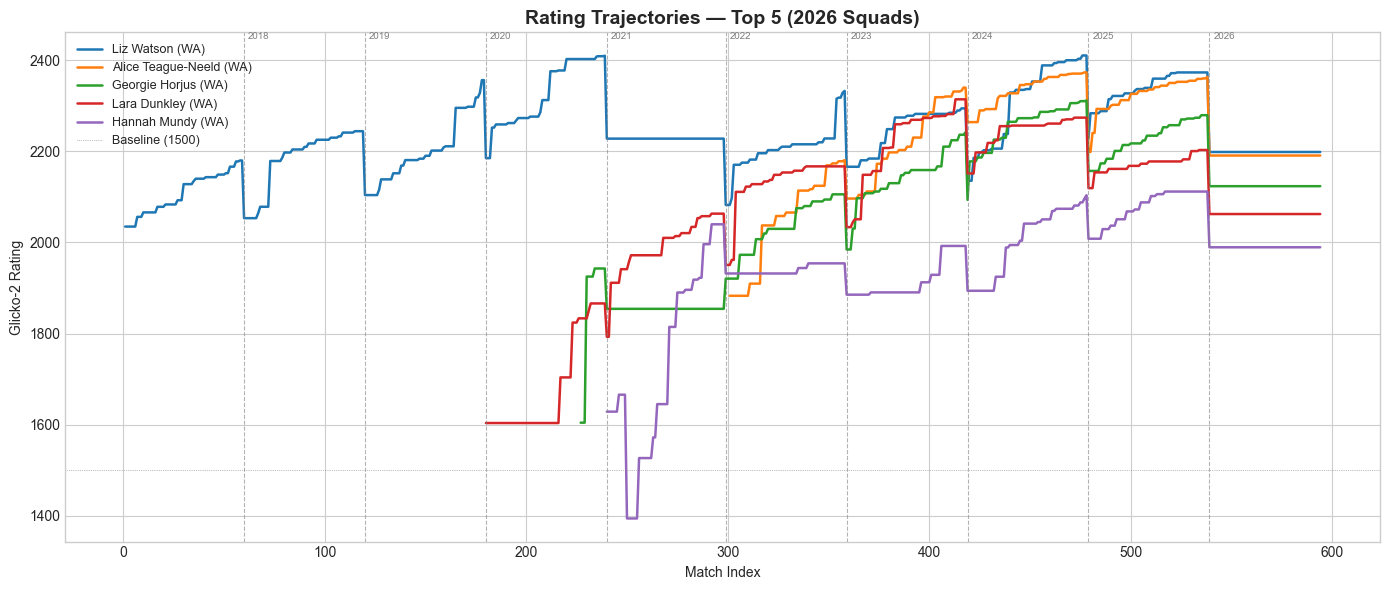

In [9]:
# Find top 5 among 2026 squad players by final rating
final_ratings = []
for (pid, pos), pr in glicko._ratings.items():
    if pid not in squad_2026_pids:
        continue
    info = player_map.get(pid, {})
    final_ratings.append({
        'player_id': pid,
        'position': pos,
        'player_name': info.get('player_name', f'Player {pid}'),
        'team': info.get('team', '?'),
        'rating': pr.rating,
    })

top5 = pd.DataFrame(final_ratings).sort_values('rating', ascending=False).head(5)
print('Top 5 rated 2026 squad players:')
display(top5[['player_name', 'position', 'team', 'rating']].style
        .format({'rating': '{:.0f}'}).hide(axis='index'))

# Plot trajectories
fig, ax = plt.subplots(figsize=(14, 6))

for _, row in top5.iterrows():
    pid = row['player_id']
    pos = row['position']
    ph = history_df[(history_df['player_id'] == pid) & (history_df['position'] == pos)]
    ph = ph.sort_values('match_index')
    ax.plot(ph['match_index'], ph['rating'], linewidth=1.8,
            label=f"{row['player_name']} ({pos})")

for sb in season_boundaries:
    ax.axvline(sb, color='grey', ls='--', lw=0.8, alpha=0.6)

ymax = ax.get_ylim()[1]
for sb in season_boundaries:
    season_label = matches[sb].get('season', '?')
    ax.text(sb + 2, ymax, str(season_label), fontsize=7, color='grey', va='top')

ax.axhline(1500, color='grey', ls=':', lw=0.5, label='Baseline (1500)')
ax.set_xlabel('Match Index')
ax.set_ylabel('Glicko-2 Rating')
ax.set_title('Rating Trajectories \u2014 Top 5 (2026 Squads)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## Head-to-Head Matchup Heatmaps — 2026 Squads

For each positional pairing, win probability for the attacker (row) against each
defender (column) among 2026 squad players. Values above 0.50 favour the attacker.

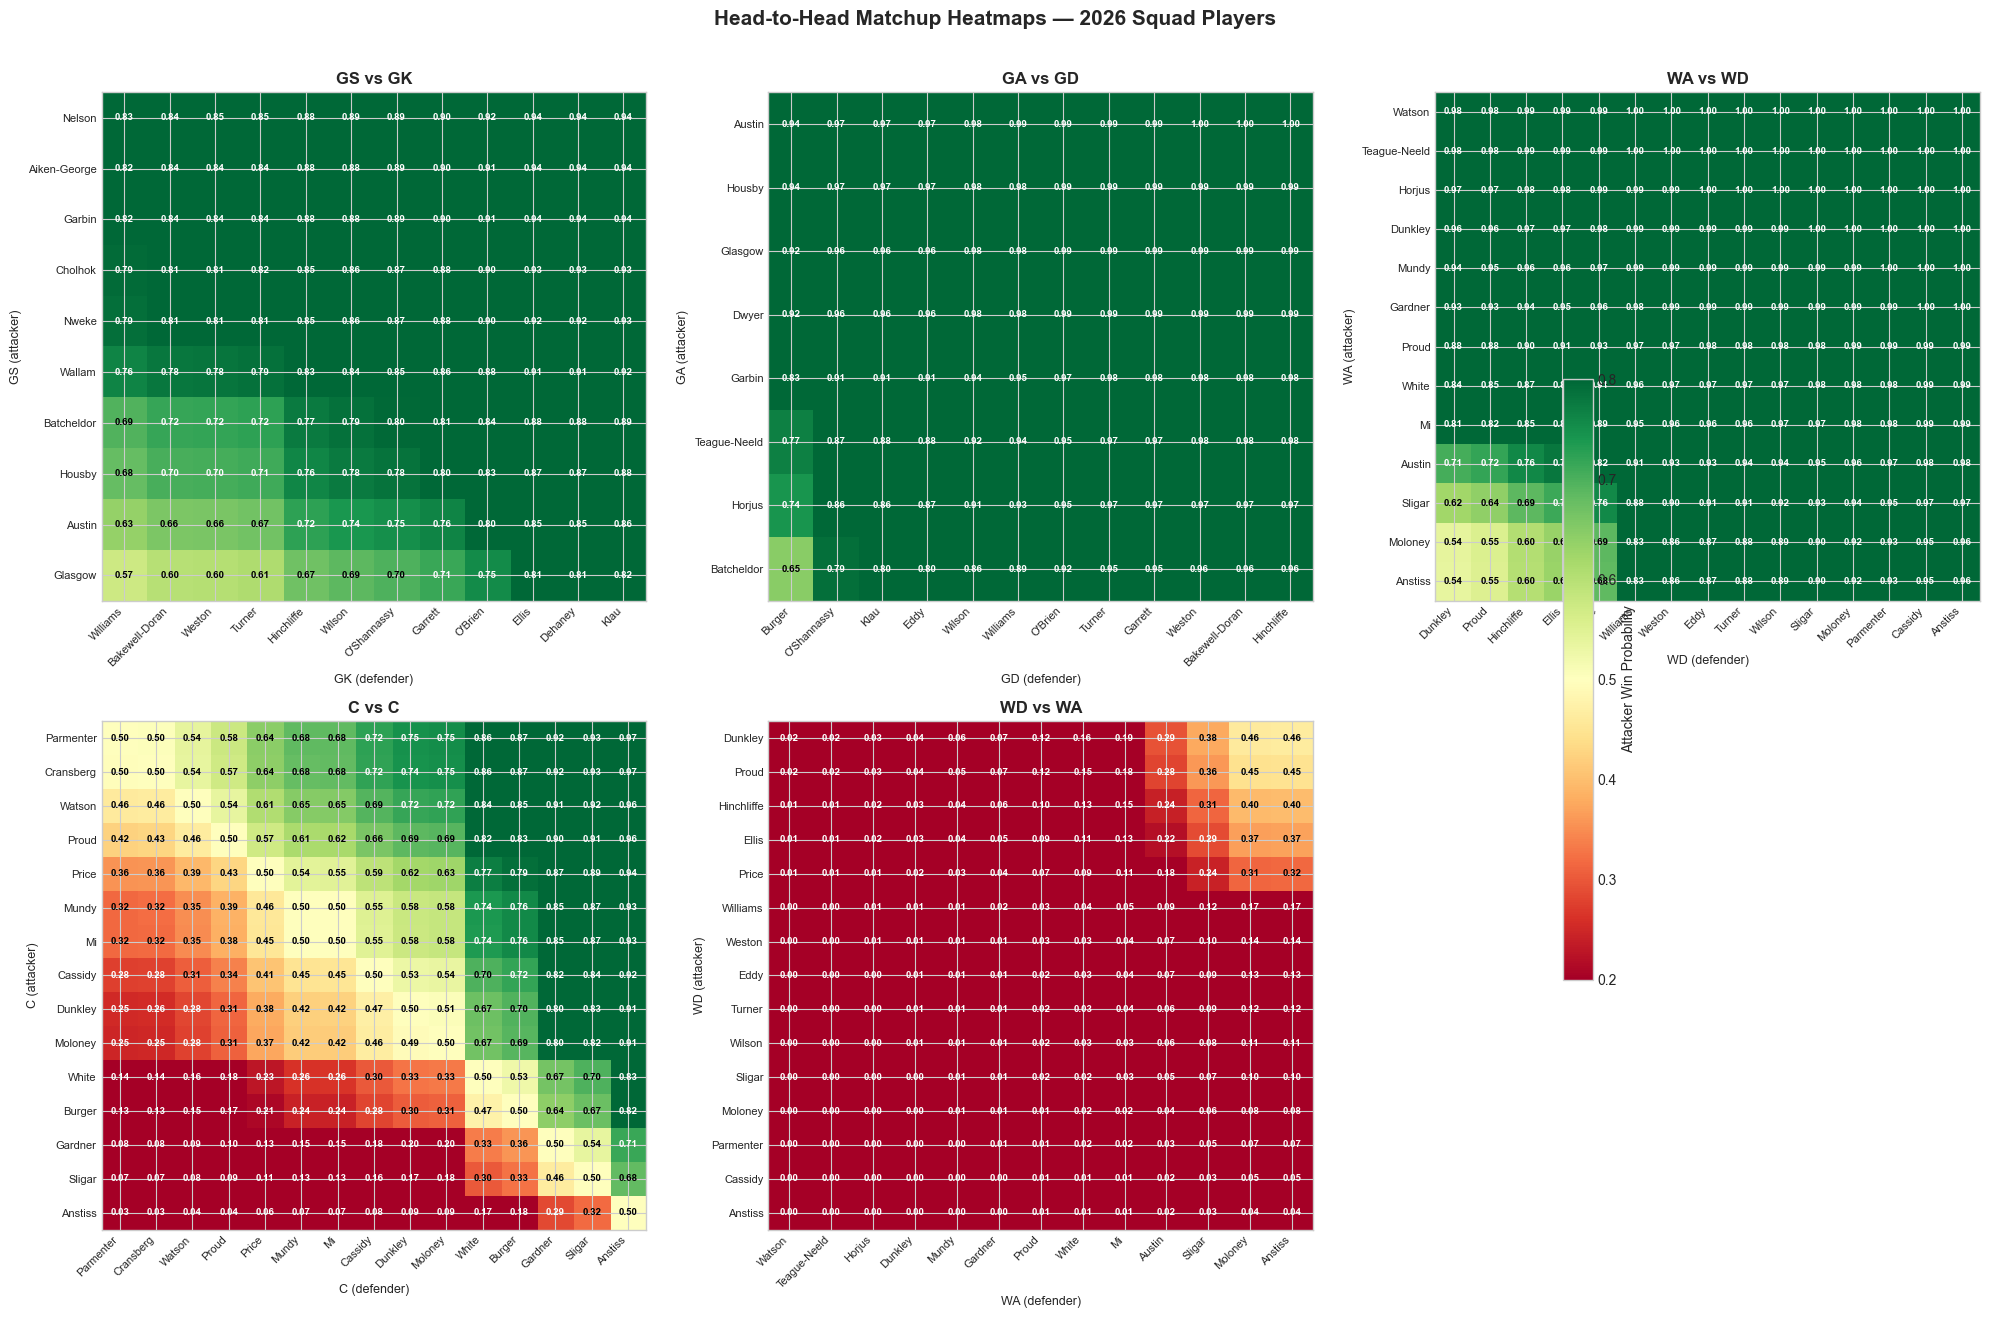

In [10]:
pairings = [
    ('GS', 'GK', 'GS vs GK'),
    ('GA', 'GD', 'GA vs GD'),
    ('WA', 'WD', 'WA vs WD'),
    ('C', 'C', 'C vs C'),
    ('WD', 'WA', 'WD vs WA'),
]

fig, axes = plt.subplots(2, 3, figsize=(20, 13))
axes = axes.flatten()

for idx, (att_pos, def_pos, label) in enumerate(pairings):
    ax = axes[idx]

    att_rankings = [r for r in get_position_rankings(glicko, player_map, att_pos)
                    if r['player_id'] in squad_2026_pids]
    def_rankings = [r for r in get_position_rankings(glicko, player_map, def_pos)
                    if r['player_id'] in squad_2026_pids]

    if not att_rankings or not def_rankings:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center')
        ax.set_title(label, fontsize=12, fontweight='bold')
        continue

    n_att = len(att_rankings)
    n_def = len(def_rankings)

    att_names = [r['player_name'] for r in att_rankings]
    def_names = [r['player_name'] for r in def_rankings]
    att_ids = [r['player_id'] for r in att_rankings]
    def_ids = [r['player_id'] for r in def_rankings]

    matrix = np.zeros((n_att, n_def))
    for i, a_id in enumerate(att_ids):
        for j, d_id in enumerate(def_ids):
            matrix[i, j] = glicko.get_matchup_prediction(a_id, att_pos, d_id, def_pos)

    norm = mcolors.TwoSlopeNorm(vmin=0.2, vcenter=0.5, vmax=0.8)
    im = ax.imshow(matrix, cmap='RdYlGn', norm=norm, aspect='auto')

    for i in range(n_att):
        for j in range(n_def):
            val = matrix[i, j]
            color = 'white' if abs(val - 0.5) > 0.2 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=7, color=color, fontweight='bold')

    ax.set_xticks(range(n_def))
    ax.set_xticklabels([n.split()[-1] for n in def_names], rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(n_att))
    ax.set_yticklabels([n.split()[-1] for n in att_names], fontsize=8)
    ax.set_xlabel(f'{def_pos} (defender)', fontsize=9)
    ax.set_ylabel(f'{att_pos} (attacker)', fontsize=9)
    ax.set_title(label, fontsize=12, fontweight='bold')

axes[5].set_visible(False)

cbar = fig.colorbar(im, ax=axes.tolist(), shrink=0.6, pad=0.02)
cbar.set_label('Attacker Win Probability', fontsize=10)

fig.suptitle('Head-to-Head Matchup Heatmaps \u2014 2026 Squad Players',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 2026 Team Matchup Reports

Projected positional matchups for selected 2026 season fixtures using
announced squad lineups. Win probability > 0.55 highlighted green,
< 0.45 highlighted red.

In [11]:
def style_matchup_df(report_df):
    """Apply colour styling to the home_win_prob column."""
    def color_prob(val):
        if val > 0.55:
            return 'background-color: #C8E6C9; color: #1B5E20'
        elif val < 0.45:
            return 'background-color: #FFCDD2; color: #B71C1C'
        return ''

    styled = report_df.style.applymap(
        color_prob, subset=['home_win_prob']
    ).format({
        'home_rating': '{:.0f}',
        'away_rating': '{:.0f}',
        'home_win_prob': '{:.3f}',
        'rating_diff': '{:+.0f}',
    }).hide(axis='index')
    return styled


matchup_fixtures = [
    ('Melbourne Vixens', 'Melbourne Mavericks'),
    ('NSW Swifts', 'GIANTS Netball'),
    ('Queensland Firebirds', 'Sunshine Coast Lightning'),
    ('West Coast Fever', 'Adelaide Thunderbirds'),
    ('Melbourne Vixens', 'NSW Swifts'),
    ('GIANTS Netball', 'Queensland Firebirds'),
]

for home_team, away_team in matchup_fixtures:
    home_sq = squad_ids.get(home_team, {})
    away_sq = squad_ids.get(away_team, {})
    if not home_sq or not away_sq:
        print(f'Skipping {home_team} vs {away_team} (missing squad data)')
        continue

    report = get_team_matchup_report(
        glicko, player_map,
        home_team, away_team,
        home_sq, away_sq,
    )
    if not report:
        print(f'No matchup data for {home_team} vs {away_team}')
        continue

    report_df = pd.DataFrame(report)
    print(f'\n{home_team} (home) vs {away_team} (away)')
    display(style_matchup_df(report_df))


Melbourne Vixens (home) vs Melbourne Mavericks (away)


pair,home_player,away_player,home_rating,away_rating,home_win_prob,rating_diff
GS vs GK,Sophie Garbin,Tara Hinchliffe,1745,1407,0.875,+338
WA vs WD,Hannah Mundy,Amy Parmenter,1990,1066,0.995,+923
C vs C,Kate Moloney,Jamie-Lee Price,1621,1711,0.374,-89



NSW Swifts (home) vs GIANTS Netball (away)


pair,home_player,away_player,home_rating,away_rating,home_win_prob,rating_diff
GA vs GD,Helen Housby,Erin O'Brien,1966,1183,0.989,+783
C vs C,Maddy Proud,Hope White,1761,1500,0.818,+261



Queensland Firebirds (home) vs Sunshine Coast Lightning (away)


...

pair,home_player,away_player,home_rating,away_rating,home_win_prob,rating_diff
GA vs GD,Sasha Glasgow,Matilda Garrett,1936,1088,0.992,+847
WA vs WD,Alice Teague-Neeld,Latanya Wilson,2191,1160,0.997,+1031



Melbourne Vixens (home) vs NSW Swifts (away)


pair,home_player,away_player,home_rating,away_rating,home_win_prob,rating_diff
GS vs GK,Sophie Garbin,Sarah Klau,1745,1264,0.941,+481
GA vs GD,Kiera Austin,Teigan O'Shannassy,1986,1374,0.971,+612
WA vs WD,Hannah Mundy,Maddy Turner,1990,1182,0.991,+808
C vs C,Kate Moloney,Maddy Proud,1621,1761,0.309,-139



GIANTS Netball (home) vs Queensland Firebirds (away)


pair,home_player,away_player,home_rating,away_rating,home_win_prob,rating_diff
GA vs GD,Sophie Dwyer,Ruby Bakewell-Doran,1933,1060,0.993,+874
WD vs WA,Amy Sligar,Macy Gardner,1140,1946,0.010,-805


## Best & Worst Matchups — 2026 Squad Players

For the top-rated 2026 attackers at GS, GA, and WA, their easiest and toughest
opponents among 2026 squad defenders at the opposing position.

In [12]:
attack_defence_pairs = [
    ('GS', 'GK'),
    ('GA', 'GD'),
    ('WA', 'WD'),
]

for att_pos, def_pos in attack_defence_pairs:
    att_all = [r for r in get_position_rankings(glicko, player_map, att_pos)
               if r['player_id'] in squad_2026_pids]
    att_top3 = att_all[:3]
    all_defenders = [r for r in get_position_rankings(glicko, player_map, def_pos)
                     if r['player_id'] in squad_2026_pids]

    if not att_top3 or not all_defenders:
        continue

    print(f'\n{"=" * 60}')
    print(f'  {att_pos} vs {def_pos}')
    print(f'{"=" * 60}')

    for attacker in att_top3:
        a_id = attacker['player_id']
        a_name = attacker['player_name']
        a_team = attacker['team']
        a_rating = attacker['rating']

        matchup_rows = []
        for defender in all_defenders:
            d_id = defender['player_id']
            win_prob = glicko.get_matchup_prediction(a_id, att_pos, d_id, def_pos)
            matchup_rows.append({
                'opponent': defender['player_name'],
                'opponent_team': defender['team'],
                'opponent_rating': round(defender['rating']),
                'win_prob': round(win_prob, 3),
            })

        matchup_df = pd.DataFrame(matchup_rows).sort_values('win_prob', ascending=False)
        n_show = min(3, len(matchup_df))
        easiest = matchup_df.head(n_show).reset_index(drop=True)
        toughest = matchup_df.tail(n_show).sort_values('win_prob').reset_index(drop=True)

        print(f'\n  {a_name} ({a_team}) | Rating: {a_rating:.0f}')
        print(f'  --- Easiest matchups ---')
        display(easiest.style.hide(axis='index'))
        print(f'  --- Toughest matchups ---')
        display(toughest.style.hide(axis='index'))


  GS vs GK

  Shimona Nelson (Melbourne Mavericks) | Rating: 1754
  --- Easiest matchups ---


opponent,opponent_team,opponent_rating,win_prob
Sarah Klau,NSW Swifts,1264,0.944000
Kadie-Ann Dehaney,West Coast Fever,1275,0.941000
Rudi Ellis,Melbourne Vixens,1276,0.940000


  --- Toughest matchups ---


opponent,opponent_team,opponent_rating,win_prob
Fran Williams,West Coast Fever,1479,0.830000
Ruby Bakewell-Doran,Queensland Firebirds,1461,0.844000
Jo Weston,Melbourne Vixens,1458,0.846000



  Romelda Aiken-George (Adelaide Thunderbirds) | Rating: 1746
  --- Easiest matchups ---


...

opponent,opponent_team,opponent_rating,win_prob
Lara Dunkley,Queensland Firebirds,1500,0.982000
Maddy Proud,NSW Swifts,1488,0.983000
Tara Hinchliffe,Sunshine Coast Lightning,1452,0.986000



  Georgie Horjus (Adelaide Thunderbirds) | Rating: 2124
  --- Easiest matchups ---


opponent,opponent_team,opponent_rating,win_prob
Jess Anstiss,West Coast Fever,975,0.999000
Amy Parmenter,Melbourne Mavericks,1066,0.998000
Mahalia Cassidy,Sunshine Coast Lightning,1003,0.998000


  --- Toughest matchups ---


opponent,opponent_team,opponent_rating,win_prob
Lara Dunkley,Queensland Firebirds,1500,0.973000
Maddy Proud,NSW Swifts,1488,0.975000
Tara Hinchliffe,Sunshine Coast Lightning,1452,0.979000
